<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
/var/folders/b4/2_zbw1nd54s0cdjd12nftxnm0000gn/T/ipykernel_38810/1019269952.py:41: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$M_{\mathrm{fd}}$')
/var/folders/b4/2_zbw1nd54s0cdjd12nftxnm0000gn/T/ipykernel_38810/1019269952.py:42: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$M_{\mathrm{bl}}$')
/Users/michalryngier/studia/praca-magisterska/art/Solution/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


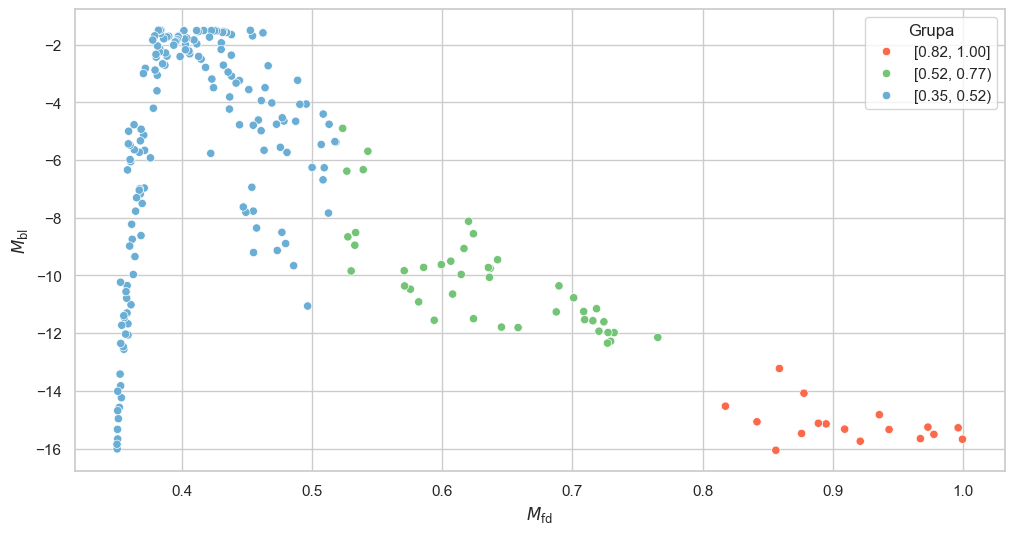

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Wczytaj plik CSV
df = pd.read_csv('benford-fractal.csv')

# Zastosuj metodę KMeans
kmeans = KMeans(n_clusters=3, random_state=2147483648)
df['Esthetics_Group'] = kmeans.fit_predict(df[['Fractal']])

# Pobierz wartości liczbowe (min i max) dla każdego klastra
cluster_ranges = df.groupby('Esthetics_Group')['Fractal'].agg(['min', 'max']).values

# Przygotuj etykiety dla legendy z różnymi rodzajami nawiasów
legend_labels = {
    0: '[0.35, 0.52)',
    1: '[0.52, 0.77)',
    2: '[0.82, 1.00]'
}

# Mapowanie klastrów do etykiet
df['Legend_Label'] = df['Esthetics_Group'].map(legend_labels)

# Utwórz scatter plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Ustawienia palety kolorów
palette = {
    '[0.35, 0.52)': sns.color_palette("Blues", n_colors=3)[1],   # Środkowy kolor z palety Blues
    '[0.52, 0.77)': sns.color_palette("Greens", n_colors=3)[1],  # Środkowy kolor z palety Greens
    '[0.82, 1.00]': sns.color_palette("Reds", n_colors=3)[1]     # Środkowy kolor z palety Reds
}

# Rysowanie scatter plot
scatterplot = sns.scatterplot(x='Fractal', y='Benford', hue='Legend_Label', palette=palette, data=df)

# Dodaj etykiety i tytuły
plt.xlabel('$M_{\mathrm{fd}}$')
plt.ylabel('$M_{\mathrm{bl}}$')

# Ustawienia legendy
plt.legend(title='Grupa')

# Wyświetl wykres
plt.show()
